In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

# scCODA
https://pertpy.readthedocs.io/en/latest/tutorials/notebooks/sccoda.html

In [2]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pertpy as pt

## Omentum

In [3]:
import anndata as ad

INPUT_DIR = "inputs"
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))

In [7]:
with pd.option_context('display.max_rows', None):
    print(adata.obs.value_counts(["cell_type_", "common_participant"]).sort_index())

cell_type_      common_participant
B_cells         Healthy_0               91
                Healthy_1               12
                Healthy_2              135
                Healthy_3               26
                Healthy_4                8
                Unhealthy_0             24
                Unhealthy_1              5
                Unhealthy_2             16
                Unhealthy_3             52
                Unhealthy_4              5
ECs             Healthy_0              150
                Healthy_1              122
                Healthy_2              119
                Healthy_3              166
                Healthy_4               33
                Unhealthy_0             42
                Unhealthy_1             48
                Unhealthy_2             52
                Unhealthy_3             47
                Unhealthy_4             91
FAPs            Healthy_0             1133
                Healthy_1             1407
                Hea

In [4]:
samples = {
    "BRI-1456": {
        "disease": "Healthy",
        "tissue": "SQ",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1457": {
        "disease": "Unhealthy",
        "tissue": "SQ",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1458": {
        "disease": "Healthy",
        "tissue": "Omentum",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
    "BRI-1459": {
        "disease": "Unhealthy",
        "tissue": "Omentum",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
}

In [5]:
adata.obs["lib_name"] = None
adata.obs.loc[adata.obs["disease"] == "Healthy", "lib_name"] = "BRI-1458"
adata.obs.loc[adata.obs["disease"] == "Unhealthy", "lib_name"] = "BRI-1459"

In [6]:
adata.obs["sex"] = None
for i, row in adata.obs.iterrows():
    adata.obs.loc[i, "sex"] = samples[row["lib_name"]]["sex"][row["assignment"]]

In [ ]:
# import anndata as ad
# ad.settings.allow_write_nullable_strings = True
# adata.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'omentum_reannotated_finely.h5ad'))

In [7]:
adata.obs.value_counts(["disease", "assignment", "sex"])

disease    assignment  sex
Healthy    1           F      3769
           2           M      3722
           0           F      3563
           3           M      2790
Unhealthy  1           F      2562
           2           M      2342
           3           M      2240
           0           F      2124
           4           F      1988
Healthy    4           F       730
Name: count, dtype: int64

In [4]:
omentum = adata

In [5]:
adata.obs

,sex,cell_type_,cell_type1_,cell_type2_,common_participant,cohort
AAACCCAAGAACTTCC-1_Healthy,M,ECs,VECs,VECs,Healthy_3,Healthy
AAACCCAAGATGTTGA-1_Healthy,M,Myofibroblasts,Myofibroblasts,Myofibroblasts,Healthy_3,Healthy
AAACCCAAGCCAAGGT-1_Healthy,M,FAPs,FAPs,FAPs,Healthy_3,Healthy
AAACCCAAGCTATCCA-1_Healthy,M,Myeloid_cells,PVMs,Macrophages,Healthy_3,Healthy
AAACCCAAGTTGCCTA-1_Healthy,F,Myeloid_cells,PVMs,Macrophages,Healthy_1,Healthy
...,...,...,...,...,...,...
TTTGTTGCACAATGCT-1_Unhealthy,F,Mesothelial,Mesothelial_cells,Mesothelial_cells,Unhealthy_4,Unhealthy
TTTGTTGGTGACTGAG-1_Unhealthy,F,FAPs,FAPs,FAPs,Unhealthy_4,Unhealthy
TTTGTTGGTTAGGACG-1_Unhealthy,F,FAPs,FAPs,FAPs,Unhealthy_0,Unhealthy
TTTGTTGTCGAGTTGT-1_Unhealthy,F,Pre_adipocytes,Pre_adipocytes,Pre_adipocytes,Unhealthy_0,Unhealthy


In [25]:
sccoda_model = pt.tl.Sccoda()
sccoda_omentum = sccoda_model.load(
    omentum,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type_",
    sample_identifier="common_participant",
    covariate_obs=["cohort", "sex"],
)
print(sccoda_omentum)
print(sccoda_omentum["coda"].X)
print(sccoda_omentum["coda"].obs)

MuData object with n_obs × n_vars = 25840 × 26169
  2 modalities
    rna:	25830 x 26158
      obs:	'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant', 'cohort', 'scCODA_sample_id'
      var:	'gene_id', 'entrez_id', 'entrez_name', 'description'
      uns:	'common_participant_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	10 x 11
      obs:	'cohort', 'sex', 'common_participant'
      var:	'n_cells'
[[9.100e+01 1.500e+02 1.133e+03 1.290e+02 3.140e+02 5.330e+02 8.800e+01
  2.720e+02 2.200e+01 6.200e+01 7.690e+02]
 [1.200e+01 1.220e+02 1.407e+03 2.900e+01 6.810e+02 5.990e+02 1.440e+02
  1.510e+02 3.000e+00 9.800e+01 5.230e+02]
 [1.350e+02 1.190e+02 9.890e+02 2.900e+01 9.150e+02 3.410e+02 7.500e+01
  3.150e+02 5.000e+00 6.000e+01 7.390e+02]
 [2.600e+01 1.660e+02 8.180e+02 1.170e+02 1.150e+02 2.750e+02 1.980e+02
  1.020e+02 2.000e+00 9.700e+01 8.740e+02]
 [8.000e+00 3.300e+01 1.450e+02 0.0

In [51]:
broad_ct_order_om = ["FAPs", "Pre adipocytes", "IGFBP2 cells", "Mesothelial", "ECs", "Myofibroblasts", "NK cells", "T cells", "B cells", "Plasma cells", "Myeloid cells"]

In [50]:
df_long["cell_type"].unique()

array(['B cells', 'ECs', 'FAPs', 'IGFBP2 cells', 'Mesothelial',
       'Myeloid cells', 'Myofibroblasts', 'NK cells', 'Plasma cells',
       'Pre adipocytes', 'T cells'], dtype=object)

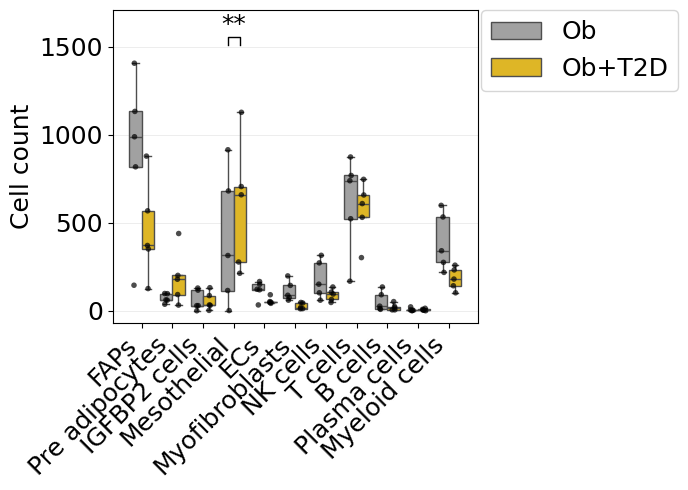

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

coda = sccoda_omentum["coda"]
df = pd.DataFrame(coda.X, index=coda.obs.index, columns=coda.var_names)
df["cohort"] = coda.obs["cohort"].map({"Healthy": "Ob", "Unhealthy": "Ob+T2D"})
df = df.rename(columns=lambda c: c.replace("_", " "))

df_long = df.melt(id_vars="cohort", var_name="cell_type", value_name="count")

cohort_colors = {"Ob": "#A1A1A1", "Ob+T2D": "#FDC707"}
cohort_order = ["Ob", "Ob+T2D"]
cell_type_order = broad_ct_order_om #sorted(df_long["cell_type"].unique())

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_long,
    x="cell_type", y="count",
    hue="cohort",
    palette=cohort_colors,
    hue_order=cohort_order,
    order=cell_type_order,
    showfliers=False,
    ax=ax,
)
sns.stripplot(
    data=df_long,
    x="cell_type", y="count",
    hue="cohort",
    palette={"Ob": "black", "Ob+T2D": "black"},
    hue_order=cohort_order,
    order=cell_type_order,
    dodge=True,
    size=4, alpha=0.7,
    legend=False,
    ax=ax,
)

# ** above Mesothelial boxes (FDR < 0.01)
ct_pos = {ct: i for i, ct in enumerate(cell_type_order)}
n_hue = 2
width = 0.8 / n_hue
x_center = ct_pos["Mesothelial"]
x1 = x_center - width / 2
x2 = x_center + width / 2

ylim = ax.get_ylim()
y_rng = ylim[1] - ylim[0]
y_top = ylim[1] + y_rng * 0.05
tick_h = y_rng * 0.03
ax.plot([x1, x1, x2, x2], [y_top - tick_h, y_top, y_top, y_top - tick_h],
        lw=1, c="black", clip_on=False)
ax.text(x_center, y_top, "**", ha="center", va="bottom", fontsize=18, clip_on=False)
# ax.text(x_center, y_top + 135, "p < 0.01", ha="center", va="bottom", fontsize=10, clip_on=False)
ax.set_ylim(ylim[0], ylim[1] + y_rng * 0.15)

ax.set_axisbelow(True)
ax.grid(axis="y", color="grey", alpha=0.2, linewidth=0.5)

ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Cell count", fontsize=18)

plt.xticks(rotation=45, ha='right')

ax.tick_params(labelsize=18)

legend = ax.legend(
    title=None, #"Cohort",
    title_fontsize=16,
    fontsize=18,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

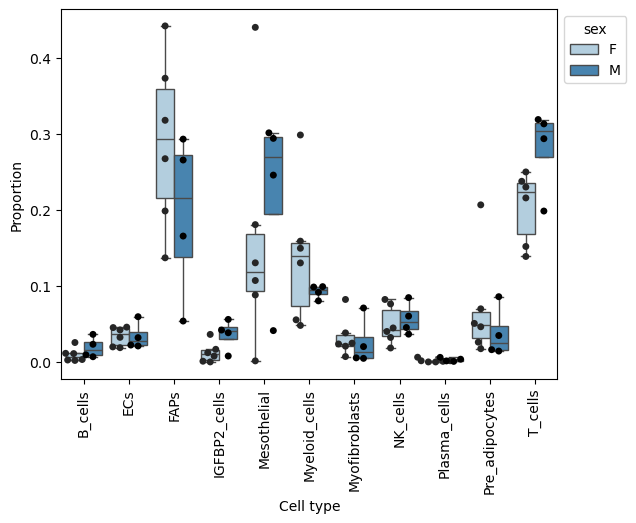

In [12]:
sccoda_model.plot_boxplots(sccoda_omentum, modality_key="coda", feature_name="sex", add_dots=True)

In [13]:
sccoda_omentum = sccoda_model.prepare(
    sccoda_omentum,
    modality_key="coda",
    formula="cohort + sex",
    reference_cell_type="ECs",
)
sccoda_omentum["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 11
    obs: 'cohort', 'sex', 'common_participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'

In [14]:
sccoda_model.run_nuts(sccoda_omentum, modality_key="coda")
sccoda_omentum["coda"]

sample: 100%|██████████████████████████████████████████████| 11000/11000 [01:31<00:00, 119.72it/s, 255 steps of size 2.05e-02. acc. prob=0.83]


AnnData object with n_obs × n_vars = 10 × 11
    obs: 'cohort', 'sex', 'common_participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_cohort[T.Unhealthy]', 'effect_df_sex[T.M]'

In [19]:
sccoda_model.set_fdr(sccoda_omentum, modality_key="coda", est_fdr=0.01)
sccoda_model.summary(sccoda_omentum, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 11 cell types                                         │
│ Reference cell type                   │ ECs                                                                     │
│ Formula                               │ cohort + sex                                                            │
│ Reference index                       │ 1                                                                       │
│ Spike-and-slab threshold              │ 0.994                                                                   │
│ Spike-and-slab threshold              │ 0.994                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 83.0%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                 Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                         │
│ cell_type_                                                                                                      │
│ B_cells             -0.447       -1.120   0.183  0.345      56.713                                              │
│ ECs                  0.333       -0.135   0.830  0.261     123.717                                              │
│ FAPs                 2.152        1.662   2.623  0.259     762.803                                              │
│ IGFBP2_cells        -0.416       -1.093   0.252  0.362      58.498                                              │
│ Mesothelial          0.756        0.126   1.379  0.338     188.859                                              │
│ Myeloid_cells        1.441        0.903   1.977  0.284     374.653                                              │
│ Myofibroblasts       0.217       -0.456   0.928  0.371     110.167                                              │
│ NK_cells             0.651        0.113   1.193  0.288     170.034                                              │
│ Plasma_cells        -1.203       -1.896  -0.540  0.367      26.629                                              │
│ Pre_adipocytes       0.382       -0.222   1.001  0.332     129.931                                              │
│ T_cells              1.880        1.422   2.352  0.251     581.145                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                   Final Parameter  Expected Sample  log2-fold change                            │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy B_cells             0.000            49.352            -0.201                                 │
│                   ECs                 0.000           107.661            -0.201                                 │
│                   FAPs                0.000           663.801            -0.201                                 │
│                   IGFBP2_cells        0.000            50.906            -0.201                                 │
│                   Mesothelial         1.112           499.606             1.403                                 │
│                   Myeloid_cells       0.000           326.028            -0.201                                 │
│                   Myofibroblasts      0.000            95.869            -0.201                                 │
│                   NK_cells            0.000           147.966            -0.201                                 │
│                   Plasma_cells        0.000            23.173            -0.201                                 │
│                   Pre_adipocytes      0.000           113.067            -0.201                                 │
│                   T_cells             0.000           505.720            -0.201                                 │
│ sexT.M            B_cells             0.000            56.713             0.000                                 │
│                   ECs                 0.000           123.717             0.000                                 │
│                   FAPs                0.000           762.803             0.000                                 │
│                   IGFBP2_cells        0.000            58.498             0.000                                 │
│                   Mesothelial         0.000           188.859             0.000                                 │
│                   Myeloid_cells       0.000           374.653             0.000                                 │
│                   Myofibroblasts      0.000           110.167             0.000                                 │
│                   NK_cells            0.000           170.034             0.000                                 │
│                   Plasma_cells        0.000            26.629             0.000                                 │
│                   Pre_adipocytes      0.000           129.931             0.000                                 │
│                   T_cells             0.000           581.145             0.000                                 │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                   HDI 3%  HDI 97%   SD   Inclusion probability                                  │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy B_cells         -1.049  0.593   0.293         0.437                                           │
│                   ECs              0.000  0.000   0.000         0.000                                           │
│                   FAPs            -0.870  0.134   0.262         0.512                                           │
│                   IGFBP2_cells    -0.651  0.937   0.291         0.445                                           │
│                   Mesothelial      0.394  1.846   0.393         0.995                                           │
│                   Myeloid_cells   -0.982  0.204   0.302         0.541                                           │
│                   Myofibroblasts  -1.405  0.202   0.434         0.610                                           │
│                   NK_cells        -0.852  0.437   0.237         0.413                                           │
│                   Plasma_cells    -0.785  0.946   0.298         0.436                                           │
│                   Pre_adipocytes  -0.161  1.371   0.430         0.644                                           │
│                   T_cells         -0.199  0.812   0.243         0.477                                           │
│ sexT.M            B_cells         -0.435  0.906   0.269         0.512                                           │
│                   ECs              0.000  0.000   0.000         0.000                                           │
│                   FAPs            -0.797  0.124   0.246         0.597                                           │
│                   IGFBP2_cells    -0.277  1.267   0.390         0.614                                           │
│                   Mesothelial     -0.099  1.082   0.351         0.735                                           │
│                   Myeloid_cells   -0.648  0.350   0.185         0.456                                           │
│                   Myofibroblasts  -0.783  0.429   0.231         0.475                                           │
│                   NK_cells        -0.440  0.686   0.203         0.458                                           │
│                   Plasma_cells    -0.553  0.817   0.245         0.487                                           │
│                   Pre_adipocytes  -0.787  0.391   0.242         0.503                                           │
│                   T_cells         -0.131  0.823   0.263         0.617                                           │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

### CD45 pos and negative

In [9]:
cd45_pos_ct = ["T_cells", "Myeloid_cells", "NK_cells", "B_cells", "Plasma_cells"]

In [10]:
adata.obs["cd45"] = "neg"
adata.obs.loc[adata.obs["cell_type_"].isin(cd45_pos_ct), "cd45"] = "pos"

In [11]:
print(adata.shape)
adata = adata[adata.obs["cell_type2_"] != "Mast_cells_",:]
print(adata.shape)

(25830, 26158)
(25729, 26158)


#### CD45+

In [12]:
omentum45 = adata[adata.obs.cd45 == "pos",:]

In [13]:
sccoda_model_om45 = pt.tl.Sccoda()

sccoda_omentum = sccoda_model_om45.load(
    omentum45,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type2_",
    sample_identifier="common_participant",
    covariate_obs=["cohort", "sex"],
)
print(sccoda_omentum)
print(sccoda_omentum["coda"].X)
print(sccoda_omentum["coda"].obs)

MuData object with n_obs × n_vars = 10492 × 26176
  2 modalities
    rna:	10482 x 26158
      obs:	'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant', 'cohort', 'cd45', 'scCODA_sample_id'
      var:	'gene_id', 'entrez_id', 'entrez_name', 'description'
      uns:	'common_participant_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	10 x 18
      obs:	'sex', 'common_participant', 'cohort'
      var:	'n_cells'
[[ 91. 309. 129.  93.  31.  12.  27.  78.  65.  90. 263.  22.  56.  12.
   87. 173.  34. 105.]
 [ 12. 301.  63.  59.  44.  24.   1.   4.  73.  27. 175.   3. 148.  78.
   38.  35.  22. 172.]
 [135. 330. 109.  98.  54.  11.  33.  57.  80.  47. 131.   5.  68.  61.
   94. 160.  10.  40.]
 [ 26. 274. 181. 183.  46.   6. 155.  12.  79.  17.  31.   2.  56.  34.
   26.  42.   1.  98.]
 [  8.  74.  20.  22.  10.   0.  10.   7.  21.  25. 136.   0.  29.  15.
   25.  20.  21.   9.]
 [ 24. 181. 

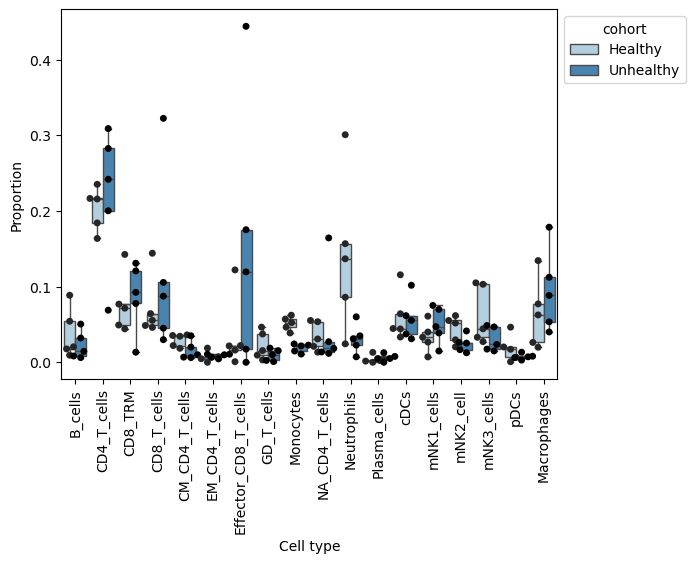

In [14]:
sccoda_model_om45.plot_boxplots(sccoda_omentum, modality_key="coda", feature_name="cohort", add_dots=True)

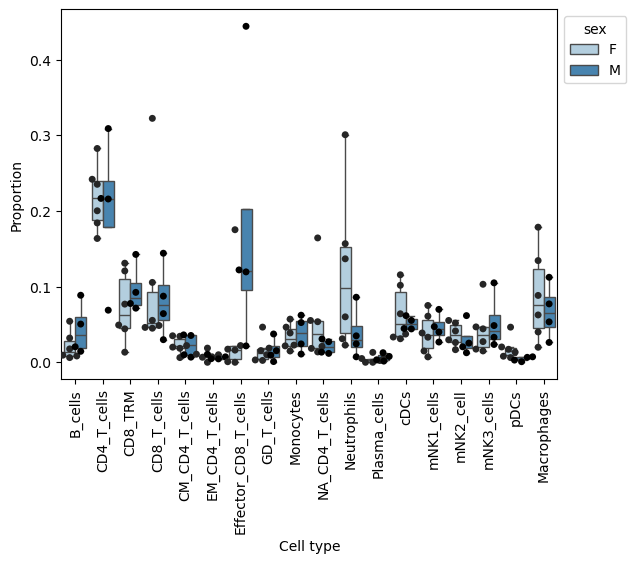

In [15]:
sccoda_model_om45.plot_boxplots(sccoda_omentum, modality_key="coda", feature_name="sex", add_dots=True)

In [17]:
sccoda_omentum = sccoda_model_om45.prepare(
    sccoda_omentum,
    modality_key="coda",
    formula="cohort + sex",
    reference_cell_type="B_cells",
)
sccoda_omentum["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 18
    obs: 'sex', 'common_participant', 'cohort'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'

In [18]:
sccoda_model_om45.run_nuts(sccoda_omentum, modality_key="coda")
sccoda_omentum["coda"]

sample: 100%|█████████████████████████████████████████████| 11000/11000 [02:02<00:00, 90.05it/s, 255 steps of size 1.92e-02. acc. prob=0.83]


AnnData object with n_obs × n_vars = 10 × 18
    obs: 'sex', 'common_participant', 'cohort'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_cohort[T.Unhealthy]', 'effect_df_sex[T.M]'

In [22]:
sccoda_model_om45.set_fdr(sccoda_omentum, modality_key="coda", est_fdr=0.05)
sccoda_model_om45.summary(sccoda_omentum, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 18 cell types                                         │
│ Reference cell type                   │ B_cells                                                                 │
│ Formula                               │ cohort + sex                                                            │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 0.897                                                                   │
│ Spike-and-slab threshold              │ 0.897                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 83.2%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                       Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                   │
│ cell_type2_                                                                                                     │
│ B_cells                    0.288       -0.226   0.766  0.266      32.102                                        │
│ CD4_T_cells                2.211        1.828   2.566  0.197     219.623                                        │
│ CD8_TRM                    1.158        0.672   1.630  0.261      76.624                                        │
│ CD8_T_cells                1.240        0.785   1.678  0.241      83.172                                        │
│ CM_CD4_T_cells             0.274       -0.387   0.881  0.335      31.656                                        │
│ EM_CD4_T_cells            -0.449       -1.135   0.181  0.351      15.362                                        │
│ Effector_CD8_T_cells      -0.355       -1.139   0.463  0.428      16.876                                        │
│ GD_T_cells                -0.162       -0.833   0.486  0.350      20.469                                        │
│ Monocytes                  0.727        0.115   1.372  0.342      49.795                                        │
│ NA_CD4_T_cells             0.544       -0.029   1.085  0.296      41.468                                        │
│ Neutrophils                1.854        1.101   2.493  0.376     153.686                                        │
│ Plasma_cells              -0.793       -1.497  -0.094  0.376      10.891                                        │
│ cDCs                       0.990        0.512   1.473  0.258      64.775                                        │
│ mNK1_cells                 0.532       -0.048   1.046  0.298      40.973                                        │
│ mNK2_cell                  0.610        0.044   1.168  0.305      44.297                                        │
│ mNK3_cells                 0.790        0.213   1.377  0.312      53.033                                        │
│ pDCs                      -0.168       -0.867   0.584  0.385      20.347                                        │
│ Macrophages                1.113        0.579   1.570  0.264      73.253                                        │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                         Final Parameter  Expected Sample  log2-fold change                      │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy B_cells                    0.000           35.440             0.143                           │
│                   CD4_T_cells                0.000          242.464             0.143                           │
│                   CD8_TRM                    0.000           84.593             0.143                           │
│                   CD8_T_cells                0.000           91.822             0.143                           │
│                   CM_CD4_T_cells             0.000           34.948             0.143                           │
│                   EM_CD4_T_cells             0.000           16.960             0.143                           │
│                   Effector_CD8_T_cells       0.000           18.631             0.143                           │
│                   GD_T_cells                 0.000           22.598             0.143                           │
│                   Monocytes                  0.000           54.974             0.143                           │
│                   NA_CD4_T_cells             0.000           45.780             0.143                           │
│                   Neutrophils               -1.029           60.637            -1.342                           │
│                   Plasma_cells               0.000           12.023             0.143                           │
│                   cDCs                       0.000           71.511             0.143                           │
│                   mNK1_cells                 0.000           45.234             0.143                           │
│                   mNK2_cell                  0.000           48.904             0.143                           │
│                   mNK3_cells                 0.000           58.548             0.143                           │
│                   pDCs                       0.000           22.463             0.143                           │
│                   Macrophages                0.000           80.871             0.143                           │
│ sexT.M            B_cells                    0.000           32.863             0.034                           │
│                   CD4_T_cells                0.000          224.831             0.034                           │
│                   CD8_TRM                    0.000           78.441             0.034                           │
│                   CD8_T_cells                0.000           85.144             0.034                           │
│                   CM_CD4_T_cells             0.000           32.406             0.034                           │
│                   EM_CD4_T_cells             0.000           15.727             0.034                           │
│                   Effector_CD8_T_cells       1.566           82.722             2.293                           │
│                   GD_T_cells                 0.000           20.954             0.034                           │
│                   Monocytes                  0.000           50.976             0.034                           │
│                   NA_CD4_T_cells             0.000           42.451             0.034                           │
│                   Neutrophils               -0.853           67.025            -1.197                           │
│                   Plasma_cells               0.000    

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                         HDI 3%  HDI 97%   SD   Inclusion probability                            │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy B_cells                0.000   0.000  0.000         0.000                                     │
│                   CD4_T_cells           -0.506   0.315  0.133         0.343                                     │
│                   CD8_TRM               -0.556   0.536  0.176         0.380                                     │
│                   CD8_T_cells           -0.419   0.676  0.196         0.411                                     │
│                   CM_CD4_T_cells        -1.095   0.358  0.343         0.538                                     │
│                   EM_CD4_T_cells        -0.721   0.834  0.274         0.443                                     │
│                   Effector_CD8_T_cells  -0.003   1.498  0.454         0.895                                     │
│                   GD_T_cells            -1.113   0.442  0.338         0.511                                     │
│                   Monocytes             -1.294   0.111  0.422         0.689                                     │
│                   NA_CD4_T_cells        -0.781   0.546  0.225         0.421                                     │
│                   Neutrophils           -1.747  -0.242  0.416         0.980                                     │
│                   Plasma_cells          -0.734   0.875  0.285         0.456                                     │
│                   cDCs                  -0.575   0.580  0.193         0.397                                     │
│                   mNK1_cells            -0.446   0.848  0.250         0.456                                     │
│                   mNK2_cell             -1.042   0.343  0.306         0.500                                     │
│                   mNK3_cells            -1.158   0.202  0.345         0.571                                     │
│                   pDCs                  -0.941   0.612  0.291         0.459                                     │
│                   Macrophages           -0.280   0.855  0.241         0.460                                     │
│ sexT.M            B_cells                0.000   0.000  0.000         0.000                                     │
│                   CD4_T_cells           -0.585   0.297  0.151         0.347                                     │
│                   CD8_TRM               -0.203   1.002  0.291         0.501                                     │
│                   CD8_T_cells           -0.635   0.517  0.174         0.337                                     │
│                   CM_CD4_T_cells        -0.836   0.704  0.256         0.392                                     │
│                   EM_CD4_T_cells        -0.885   0.775  0.282         0.415                                     │
│                   Effector_CD8_T_cells   0.646   2.432  0.486         0.993                                     │
│                   GD_T_cells            -0.828   0.817  0.277         0.415                                     │
│                   Monocytes             -0.653   0.697  0.221         0.386                                     │
│                   NA_CD4_T_cells        -1.068   0.361  0.310         0.463                                     │
│                   Neutrophils           -1.475   0.001  0.441         0.897                                     │
│                   Plasma_cells          -0.683   1.065

#### CD45-

In [23]:
omentum45_neg = adata[adata.obs.cd45 == "neg",:]

In [24]:
sccoda_model_om45_ = pt.tl.Sccoda()
sccoda_omentum = sccoda_model_om45_.load(
    omentum45_neg,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type2_",
    sample_identifier="common_participant",
    covariate_obs=["cohort", "sex"],
)
print(sccoda_omentum)
print(sccoda_omentum["coda"].X)
print(sccoda_omentum["coda"].obs)

MuData object with n_obs × n_vars = 15257 × 26166
  2 modalities
    rna:	15247 x 26158
      obs:	'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant', 'cohort', 'cd45', 'scCODA_sample_id'
      var:	'gene_id', 'entrez_id', 'entrez_name', 'description'
      uns:	'common_participant_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	10 x 8
      obs:	'sex', 'common_participant', 'cohort'
      var:	'n_cells'
[[1.133e+03 1.290e+02 1.100e+01 1.000e+00 3.130e+02 8.800e+01 6.200e+01
  1.390e+02]
 [1.407e+03 2.900e+01 2.700e+01 9.000e+00 6.720e+02 1.440e+02 9.800e+01
  9.500e+01]
 [9.890e+02 2.900e+01 1.900e+01 1.000e+01 9.050e+02 7.500e+01 6.000e+01
  1.000e+02]
 [8.180e+02 1.170e+02 5.300e+01 0.000e+00 1.150e+02 1.980e+02 9.700e+01
  1.130e+02]
 [1.450e+02 0.000e+00 3.000e+00 0.000e+00 1.000e+00 6.000e+01 3.700e+01
  3.000e+01]
 [5.680e+02 2.000e+00 1.900e+01 4.000e+00 2.730e+02 4.400e+01 4

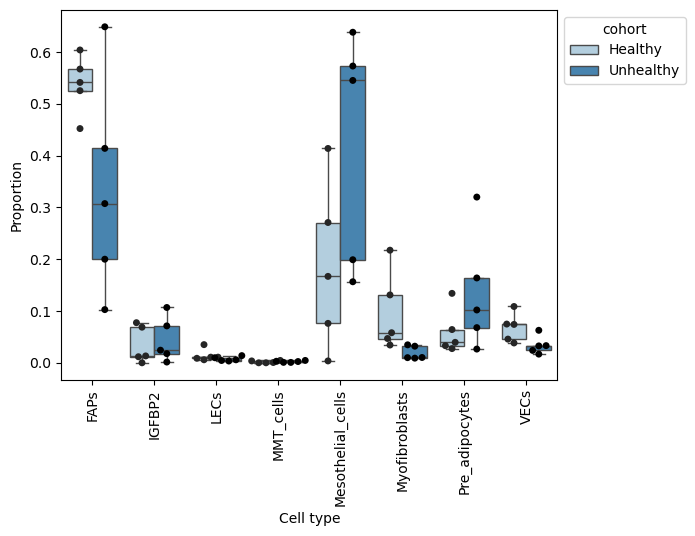

In [25]:
sccoda_model_om45_.plot_boxplots(sccoda_omentum, modality_key="coda", feature_name="cohort", add_dots=True)

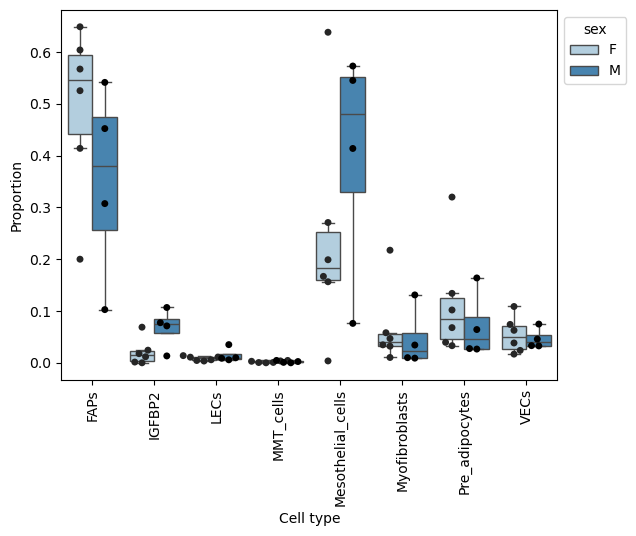

In [26]:
sccoda_model_om45_.plot_boxplots(sccoda_omentum, modality_key="coda", feature_name="sex", add_dots=True)

In [27]:
sccoda_omentum = sccoda_model_om45_.prepare(
    sccoda_omentum,
    modality_key="coda",
    formula="cohort + sex",
    reference_cell_type="VECs",
)
sccoda_omentum["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 8
    obs: 'sex', 'common_participant', 'cohort'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'

In [28]:
sccoda_model_om45_.run_nuts(sccoda_omentum, modality_key="coda")
sccoda_omentum["coda"]

sample: 100%|████████████████████████████████████████████| 11000/11000 [00:59<00:00, 185.60it/s, 127 steps of size 2.46e-02. acc. prob=0.79]


AnnData object with n_obs × n_vars = 10 × 8
    obs: 'sex', 'common_participant', 'cohort'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_cohort[T.Unhealthy]', 'effect_df_sex[T.M]'

In [33]:
sccoda_model_om45_.set_fdr(sccoda_omentum, modality_key="coda", est_fdr=0.05)
sccoda_model_om45_.summary(sccoda_omentum, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 8 cell types                                          │
│ Reference cell type                   │ VECs                                                                    │
│ Formula                               │ cohort + sex                                                            │
│ Reference index                       │ 7                                                                       │
│ Spike-and-slab threshold              │ 0.954                                                                   │
│ Spike-and-slab threshold              │ 0.954                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 79.4%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                    Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                      │
│ cell_type2_                                                                                                     │
│ FAPs                    2.141        1.539   2.768  0.329     840.516                                           │
│ IGFBP2                 -0.512       -1.281   0.202  0.397      59.206                                           │
│ LECs                   -0.744       -1.425  -0.094  0.356      46.947                                           │
│ MMT_cells              -1.337       -2.087  -0.669  0.384      25.946                                           │
│ Mesothelial_cells       0.587       -0.179   1.356  0.414     177.686                                           │
│ Myofibroblasts          0.222       -0.532   1.001  0.414     123.349                                           │
│ Pre_adipocytes          0.336       -0.373   0.953  0.355     138.243                                           │
│ VECs                    0.134       -0.436   0.653  0.292     112.958                                           │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                      Final Parameter  Expected Sample  log2-fold change                         │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy FAPs                   0.000           683.267            -0.299                              │
│                   IGFBP2                 0.000            48.129            -0.299                              │
│                   LECs                   0.000            38.164            -0.299                              │
│                   MMT_cells              0.000            21.092            -0.299                              │
│                   Mesothelial_cells      1.090           429.721             1.274                              │
│                   Myofibroblasts         0.000           100.272            -0.299                              │
│                   Pre_adipocytes         0.000           112.380            -0.299                              │
│                   VECs                   0.000            91.825            -0.299                              │
│ sexT.M            FAPs                   0.000           840.516             0.000                              │
│                   IGFBP2                 0.000            59.206             0.000                              │
│                   LECs                   0.000            46.947             0.000                              │
│                   MMT_cells              0.000            25.946             0.000                              │
│                   Mesothelial_cells      0.000           177.686             0.000                              │
│                   Myofibroblasts         0.000           123.349             0.000                              │
│                   Pre_adipocytes         0.000           138.243             0.000                              │
│                   VECs                   0.000           112.958             0.000                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                      HDI 3%  HDI 97%   SD   Inclusion probability                               │
│ Covariate         Cell Type                                                                                     │
│ cohortT.Unhealthy FAPs               -1.190  0.110   0.388         0.634                                        │
│                   IGFBP2             -0.587  1.095   0.313         0.437                                        │
│                   LECs               -1.021  0.709   0.290         0.405                                        │
│                   MMT_cells          -0.886  0.948   0.298         0.403                                        │
│                   Mesothelial_cells   0.257  1.962   0.495         0.954                                        │
│                   Myofibroblasts     -1.538  0.217   0.497         0.646                                        │
│                   Pre_adipocytes     -0.296  1.391   0.427         0.590                                        │
│                   VECs                0.000  0.000   0.000         0.000                                        │
│ sexT.M            FAPs               -0.839  0.252   0.238         0.477                                        │
│                   IGFBP2             -0.268  1.584   0.512         0.659                                        │
│                   LECs               -0.602  0.939   0.275         0.454                                        │
│                   MMT_cells          -0.824  0.781   0.282         0.470                                        │
│                   Mesothelial_cells  -0.040  1.431   0.468         0.828                                        │
│                   Myofibroblasts     -0.900  0.536   0.255         0.443                                        │
│                   Pre_adipocytes     -0.812  0.494   0.244         0.443                                        │
│                   VECs                0.000  0.000   0.000         0.000                                        │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

## SubQ

In [69]:
import anndata as ad

INPUT_DIR = "inputs"
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", 'sq_reannotated_finely.h5ad'))

In [49]:
with pd.option_context('display.max_rows', None):
    print(adata.obs.value_counts(["cell_type", "participant"]).sort_index())

cell_type       participant   
B cells         SQ_Healthy_0         6
                SQ_Healthy_1         5
                SQ_Healthy_4        11
                SQ_Unhealthy_0       2
                SQ_Unhealthy_2      14
                SQ_Unhealthy_3       1
                SQ_Unhealthy_4       3
ECs             SQ_Healthy_0        20
                SQ_Healthy_1        19
                SQ_Healthy_2        19
                SQ_Healthy_3         1
                SQ_Healthy_4         7
                SQ_Unhealthy_0     404
                SQ_Unhealthy_1      13
                SQ_Unhealthy_2      29
                SQ_Unhealthy_3      30
                SQ_Unhealthy_4       7
FAPs            SQ_Healthy_0       530
                SQ_Healthy_1       177
                SQ_Healthy_2       151
                SQ_Healthy_3        36
                SQ_Healthy_4       870
                SQ_Unhealthy_0    1244
                SQ_Unhealthy_1     251
                SQ_Unhealthy_2   

In [50]:
samples = {
    "BRI-1456": {
        "disease": "Healthy",
        "tissue": "SQ",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1457": {
        "disease": "Unhealthy",
        "tissue": "SQ",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1458": {
        "disease": "Healthy",
        "tissue": "Omentum",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
    "BRI-1459": {
        "disease": "Unhealthy",
        "tissue": "Omentum",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
}

In [51]:
adata.obs["lib_name"] = None
adata.obs.loc[adata.obs["disease"] == "Healthy", "lib_name"] = "BRI-1456"
adata.obs.loc[adata.obs["disease"] == "Unhealthy", "lib_name"] = "BRI-1457"

In [52]:
adata.obs["sex"] = None
for i, row in adata.obs.iterrows():
    adata.obs.loc[i, "sex"] = samples[row["lib_name"]]["sex"][row["assignment"]]

In [53]:
adata.obs.value_counts(["disease", "assignment", "sex"]).sort_index()

disease    assignment  sex
Healthy    0           F       818
           1           F       374
           2           F       356
           3           M        80
           4           M      1443
Unhealthy  0           F      2623
           1           F       453
           2           F      2107
           3           M       811
           4           M        62
Name: count, dtype: int64

In [70]:
sq = adata

In [71]:
sccoda_model = pt.tl.Sccoda()
sccoda_sq = sccoda_model.load(
    sq,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type",
    sample_identifier="common_participant",
    covariate_obs=["cohort", "sex"],
)
print(sccoda_sq)
print(sccoda_sq["coda"].X)
print(sccoda_sq["coda"].obs)

MuData object with n_obs × n_vars = 9137 × 22659
  var:	'n_cells'
  2 modalities
    rna:	9127 x 22651
      obs:	'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_

In [80]:
broad_ct_order_sq = ['FAPs',
 'Pre-adipocytes',
 'ECs',
 'Myofibroblasts',
 'NK cells',
 'T cells',
 'B cells',
 'Myeloid cells']

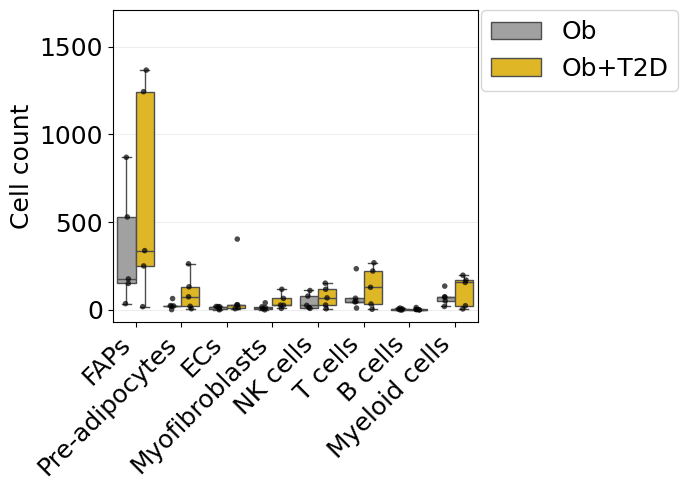

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

coda = sccoda_sq["coda"]
df = pd.DataFrame(coda.X, index=coda.obs.index, columns=coda.var_names)
df["cohort"] = coda.obs["cohort"].map({"Healthy": "Ob", "Unhealthy": "Ob+T2D"})
df = df.rename(columns=lambda c: c.replace("_", " "))

df_long = df.melt(id_vars="cohort", var_name="cell_type", value_name="count")

cohort_colors = {"Ob": "#A1A1A1", "Ob+T2D": "#FDC707"}
cohort_order = ["Ob", "Ob+T2D"]
cell_type_order = broad_ct_order_sq #sorted(df_long["cell_type"].unique())

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_long,
    x="cell_type", y="count",
    hue="cohort",
    palette=cohort_colors,
    hue_order=cohort_order,
    order=cell_type_order,
    showfliers=False,
    ax=ax,
)
sns.stripplot(
    data=df_long,
    x="cell_type", y="count",
    hue="cohort",
    palette={"Ob": "black", "Ob+T2D": "black"},
    hue_order=cohort_order,
    order=cell_type_order,
    dodge=True,
    size=4, alpha=0.7,
    legend=False,
    ax=ax,
)

# # ** above Mesothelial boxes (FDR < 0.01)
# ct_pos = {ct: i for i, ct in enumerate(cell_type_order)}
# n_hue = 2
# width = 0.8 / n_hue
# x_center = ct_pos["Mesothelial"]
# x1 = x_center - width / 2
# x2 = x_center + width / 2

# ylim = ax.get_ylim()
# y_rng = ylim[1] - ylim[0]
# y_top = ylim[1] + y_rng * 0.05
# tick_h = y_rng * 0.03
# ax.plot([x1, x1, x2, x2], [y_top - tick_h, y_top, y_top, y_top - tick_h],
#         lw=1, c="black", clip_on=False)
# ax.text(x_center, y_top, "**", ha="center", va="bottom", fontsize=18, clip_on=False)
# # ax.text(x_center, y_top + 135, "p < 0.01", ha="center", va="bottom", fontsize=10, clip_on=False)
ax.set_ylim(ylim[0], ylim[1] + y_rng * 0.15)

ax.set_axisbelow(True)
ax.grid(axis="y", color="grey", alpha=0.2, linewidth=0.5)

ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Cell count", fontsize=18)

plt.xticks(rotation=45, ha='right')

ax.tick_params(labelsize=18)

legend = ax.legend(
    title=None, #"Cohort",
    title_fontsize=16,
    fontsize=18,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

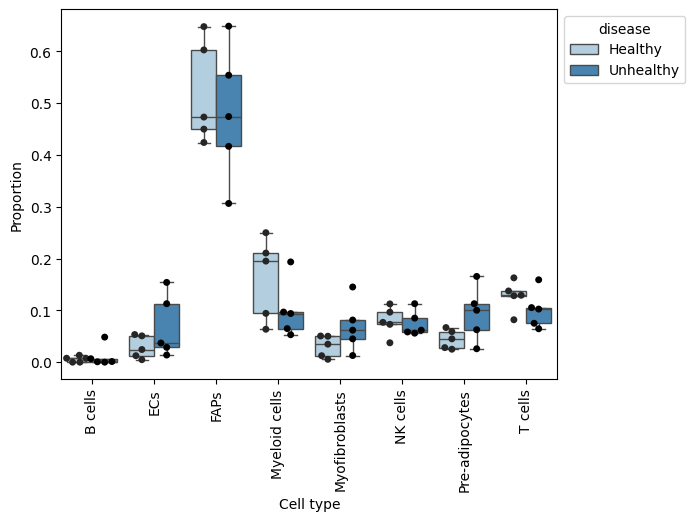

In [56]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="disease", add_dots=True)

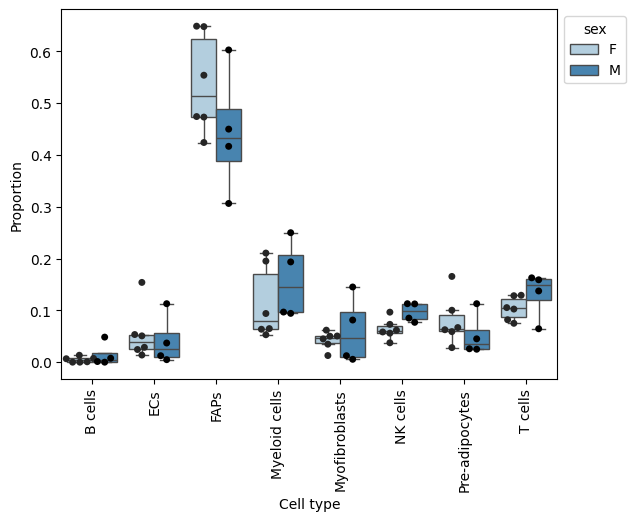

In [57]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="sex", add_dots=True)

In [58]:
sccoda_sq = sccoda_model.prepare(
    sccoda_sq,
    modality_key="coda",
    formula="disease + sex",
    reference_cell_type="ECs",
)
sccoda_sq["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 8
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'

In [59]:
sccoda_model.run_nuts(sccoda_sq, modality_key="coda")
sccoda_sq["coda"]

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11000/11000 [00:55<00:00, 199.84it/s, 127 steps of size 3.09e-02. acc. prob=0.83]


AnnData object with n_obs × n_vars = 10 × 8
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_disease[T.Unhealthy]', 'effect_df_sex[T.M]'

In [61]:
sccoda_model.set_fdr(sccoda_sq, modality_key="coda", est_fdr=0.2)
sccoda_model.summary(sccoda_sq, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 8 cell types                                          │
│ Reference cell type                   │ ECs                                                                     │
│ Formula                               │ disease + sex                                                           │
│ Reference index                       │ 1                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 83.1%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                 Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                         │
│ cell_type                                                                                                       │
│ B cells             -0.659       -1.337  -0.001  0.357      10.843                                              │
│ ECs                  0.571        0.036   1.110  0.286      37.096                                              │
│ FAPs                 3.125        2.647   3.578  0.249     477.001                                              │
│ Myeloid cells        1.675        1.129   2.183  0.281     111.890                                              │
│ Myofibroblasts       0.592       -0.008   1.162  0.317      37.884                                              │
│ NK cells             1.219        0.676   1.717  0.279      70.918                                              │
│ Pre-adipocytes       1.038        0.489   1.620  0.303      59.176                                              │
│ T cells              1.640        1.120   2.162  0.273     108.042                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy B cells             0.000            10.843            0.000                                 │
│                    ECs                 0.000            37.096            0.000                                 │
│                    FAPs                0.000           477.001            0.000                                 │
│                    Myeloid cells       0.000           111.890            0.000                                 │
│                    Myofibroblasts      0.000            37.884            0.000                                 │
│                    NK cells            0.000            70.918            0.000                                 │
│                    Pre-adipocytes      0.000            59.176            0.000                                 │
│                    T cells             0.000           108.042            0.000                                 │
│ sexT.M             B cells             0.000            10.843            0.000                                 │
│                    ECs                 0.000            37.096            0.000                                 │
│                    FAPs                0.000           477.001            0.000                                 │
│                    Myeloid cells       0.000           111.890            0.000                                 │
│                    Myofibroblasts      0.000            37.884            0.000                                 │
│                    NK cells            0.000            70.918            0.000                                 │
│                    Pre-adipocytes      0.000            59.176            0.000                                 │
│                    T cells             0.000           108.042            0.000                                 │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy B cells         -0.762  0.470   0.224         0.500                                          │
│                    ECs              0.000  0.000   0.000         0.000                                          │
│                    FAPs            -0.450  0.230   0.127         0.428                                          │
│                    Myeloid cells   -0.727  0.183   0.222         0.552                                          │
│                    Myofibroblasts  -0.288  0.842   0.253         0.535                                          │
│                    NK cells        -0.506  0.361   0.147         0.450                                          │
│                    Pre-adipocytes  -0.225  0.789   0.230         0.533                                          │
│                    T cells         -0.560  0.271   0.163         0.475                                          │
│ sexT.M             B cells         -0.465  0.682   0.212         0.498                                          │
│                    ECs              0.000  0.000   0.000         0.000                                          │
│                    FAPs            -0.574  0.128   0.163         0.531                                          │
│                    Myeloid cells   -0.223  0.676   0.187         0.507                                          │
│                    Myofibroblasts  -0.532  0.474   0.180         0.479                                          │
│                    NK cells        -0.296  0.634   0.187         0.499                                          │
│                    Pre-adipocytes  -0.798  0.259   0.232         0.539                                          │
│                    T cells         -0.295  0.569   0.164         0.467                                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

### CD45 pos and negative

#### CD45+

In [62]:
sq45 = adata[adata.obs.cd45 == "pos",:]

In [63]:
sccoda_model = pt.tl.Sccoda()
sccoda_sq = sccoda_model.load(
    sq45,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type1",
    sample_identifier="participant",
    covariate_obs=["disease", "sex"],
)
print(sccoda_omentum)
print(sccoda_omentum["coda"].X)
print(sccoda_omentum["coda"].obs)

MuData object with n_obs × n_vars = 10593 × 26179
  var:	'n_cells'
  2 modalities
    rna:	10583 x 26158
      obs:	'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'lib_name', 'sex', 'scCODA_sample_id'
      var:	'mt', 'ribo', 'hb',

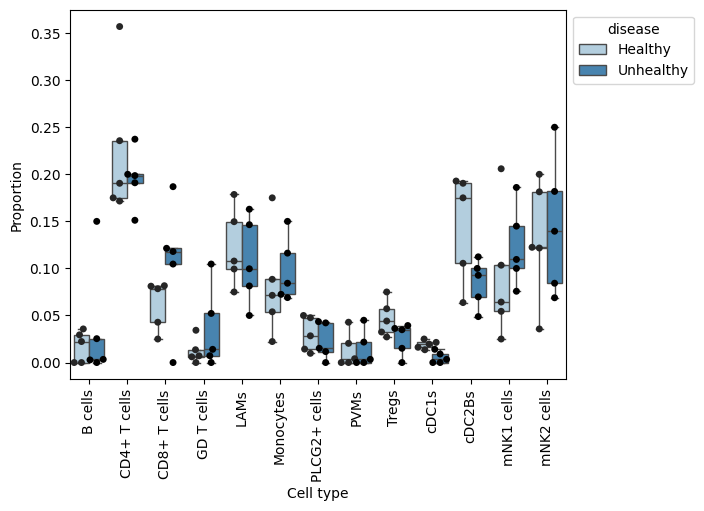

In [64]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="disease", add_dots=True)

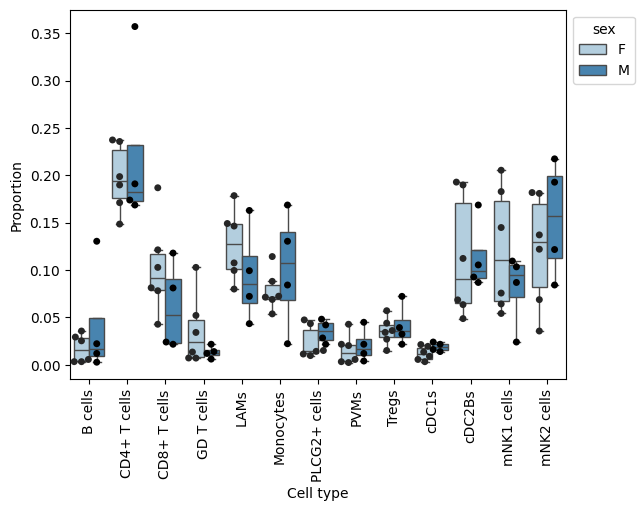

In [69]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="sex", add_dots=True)

In [66]:
sccoda_sq = sccoda_model.prepare(
    sccoda_sq,
    modality_key="coda",
    formula="disease + sex",
    reference_cell_type="B cells",
)
sccoda_omentum["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 21
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_disease[T.Unhealthy]', 'effect_df_sex[T.M]'

In [67]:
sccoda_model.run_nuts(sccoda_sq, modality_key="coda")
sccoda_omentum["coda"]

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11000/11000 [00:52<00:00, 208.02it/s, 127 steps of size 4.62e-02. acc. prob=0.70]


AnnData object with n_obs × n_vars = 10 × 21
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_disease[T.Unhealthy]', 'effect_df_sex[T.M]'

In [68]:
sccoda_model.set_fdr(sccoda_sq, modality_key="coda", est_fdr=0.2)
sccoda_model.summary(sccoda_sq, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 13 cell types                                         │
│ Reference cell type                   │ B cells                                                                 │
│ Formula                               │ disease + sex                                                           │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 70.3%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                           │
│ cell_type1                                                                                                      │
│ B cells           0.378        -0.234  0.953   0.324       5.001                                                │
│ CD4+ T cells      2.832         2.383  3.297   0.242      58.190                                                │
│ CD8+ T cells      1.917         1.381  2.433   0.277      23.306                                                │
│ GD T cells        0.580        -0.077  1.174   0.335       6.121                                                │
│ LAMs              2.274         1.800  2.740   0.251      33.305                                                │
│ Monocytes         1.748         1.281  2.245   0.258      19.682                                                │
│ PLCG2+ cells      0.839         0.257  1.433   0.316       7.930                                                │
│ PVMs              0.266        -0.387  0.916   0.349       4.471                                                │
│ Tregs             1.138         0.593  1.690   0.292      10.694                                                │
│ cDC1s             0.313        -0.316  0.972   0.341       4.687                                                │
│ cDC2Bs            2.180         1.669  2.692   0.270      30.317                                                │
│ mNK1 cells        2.104         1.603  2.572   0.259      28.098                                                │
│ mNK2 cells        2.237         1.779  2.713   0.245      32.095                                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                  Final Parameter  Expected Sample  log2-fold change                             │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy B cells           0.000             5.001            0.000                                   │
│                    CD4+ T cells      0.000            58.190            0.000                                   │
│                    CD8+ T cells      0.000            23.306            0.000                                   │
│                    GD T cells        0.000             6.121            0.000                                   │
│                    LAMs              0.000            33.305            0.000                                   │
│                    Monocytes         0.000            19.682            0.000                                   │
│                    PLCG2+ cells      0.000             7.930            0.000                                   │
│                    PVMs              0.000             4.471            0.000                                   │
│                    Tregs             0.000            10.694            0.000                                   │
│                    cDC1s             0.000             4.687            0.000                                   │
│                    cDC2Bs            0.000            30.317            0.000                                   │
│                    mNK1 cells        0.000            28.098            0.000                                   │
│                    mNK2 cells        0.000            32.095            0.000                                   │
│ sexT.M             B cells           0.000             5.001            0.000                                   │
│                    CD4+ T cells      0.000            58.190            0.000                                   │
│                    CD8+ T cells      0.000            23.306            0.000                                   │
│                    GD T cells        0.000             6.121            0.000                                   │
│                    LAMs              0.000            33.305            0.000                                   │
│                    Monocytes         0.000            19.682            0.000                                   │
│                    PLCG2+ cells      0.000             7.930            0.000                                   │
│                    PVMs              0.000             4.471            0.000                                   │
│                    Tregs             0.000            10.694            0.000                                   │
│                    cDC1s             0.000             4.687            0.000                                   │
│                    cDC2Bs            0.000            30.317            0.000                                   │
│                    mNK1 cells        0.000            28.098            0.000                                   │
│                    mNK2 cells        0.000            32.095            0.000                                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                  HDI 3%  HDI 97%   SD   Inclusion probability                                   │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy B cells        0.000  0.000   0.000         0.000                                            │
│                    CD4+ T cells  -0.419  0.209   0.122         0.471                                            │
│                    CD8+ T cells  -0.130  0.812   0.272         0.680                                            │
│                    GD T cells    -0.350  0.750   0.235         0.534                                            │
│                    LAMs          -0.351  0.327   0.114         0.433                                            │
│                    Monocytes     -0.229  0.594   0.175         0.506                                            │
│                    PLCG2+ cells  -0.432  0.503   0.167         0.486                                            │
│                    PVMs          -0.469  0.589   0.197         0.511                                            │
│                    Tregs         -0.539  0.380   0.173         0.500                                            │
│                    cDC1s         -0.730  0.365   0.212         0.521                                            │
│                    cDC2Bs        -0.703  0.122   0.217         0.610                                            │
│                    mNK1 cells    -0.230  0.502   0.149         0.492                                            │
│                    mNK2 cells    -0.349  0.315   0.117         0.453                                            │
│ sexT.M             B cells        0.000  0.000   0.000         0.000                                            │
│                    CD4+ T cells  -0.177  0.381   0.113         0.499                                            │
│                    CD8+ T cells  -0.444  0.213   0.127         0.503                                            │
│                    GD T cells    -0.509  0.309   0.169         0.530                                            │
│                    LAMs          -0.349  0.240   0.108         0.476                                            │
│                    Monocytes     -0.351  0.272   0.111         0.485                                            │
│                    PLCG2+ cells  -0.299  0.485   0.148         0.503                                            │
│                    PVMs          -0.353  0.456   0.151         0.512                                            │
│                    Tregs         -0.323  0.373   0.126         0.494                                            │
│                    cDC1s         -0.370  0.430   0.151         0.515                                            │
│                    cDC2Bs        -0.253  0.316   0.099         0.474                                            │
│                    mNK1 cells    -0.357  0.243   0.114         0.495                                            │
│                    mNK2 cells    -0.254  0.314   0.100         0.471                                            │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

#### CD45-

In [70]:
sq5_neg = adata[adata.obs.cd45 == "neg",:]

In [72]:
sccoda_model = pt.tl.Sccoda()
sccoda_sq = sccoda_model.load(
    sq5_neg,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type1",
    sample_identifier="participant",
    covariate_obs=["disease", "sex"],
)
print(sccoda_sq)
print(sccoda_sq["coda"].X)
print(sccoda_sq["coda"].obs)

MuData object with n_obs × n_vars = 6505 × 22656
  var:	'n_cells'
  2 modalities
    rna:	6495 x 22651
      obs:	'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'lib_name', 'sex', 'scCODA_sample_id'
      var:	'mt', 'ribo', 'hb', 'n_cells_by

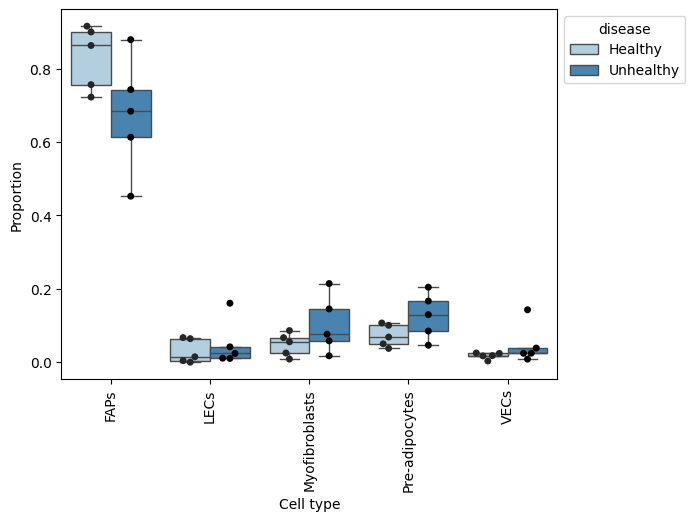

In [73]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="disease", add_dots=True)

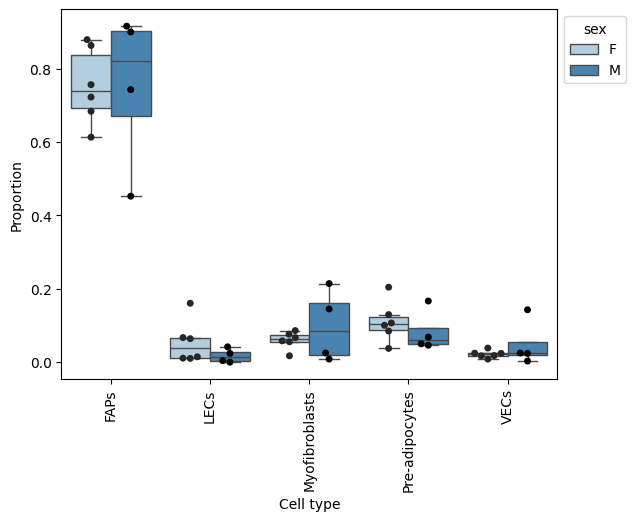

In [74]:
sccoda_model.plot_boxplots(sccoda_sq, modality_key="coda", feature_name="sex", add_dots=True)

In [75]:
sccoda_sq = sccoda_model.prepare(
    sccoda_sq,
    modality_key="coda",
    formula="disease + sex",
    reference_cell_type="VECs",
)
sccoda_sq["coda"]

• Zero counts encountered in data! Added a pseudocount of 0.5.


AnnData object with n_obs × n_vars = 10 × 5
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'

In [76]:
sccoda_model.run_nuts(sccoda_sq, modality_key="coda")
sccoda_sq["coda"]

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11000/11000 [00:57<00:00, 190.05it/s, 127 steps of size 2.44e-02. acc. prob=0.89]


AnnData object with n_obs × n_vars = 10 × 5
    obs: 'sex', 'disease', 'participant'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_disease[T.Unhealthy]', 'effect_df_sex[T.M]'

In [77]:
sccoda_model.set_fdr(sccoda_sq, modality_key="coda", est_fdr=0.2)
sccoda_model.summary(sccoda_sq, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 10 samples, 5 cell types                                          │
│ Reference cell type                   │ VECs                                                                    │
│ Formula                               │ disease + sex                                                           │
│ Reference index                       │ 4                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (1000 burnin samples)                        │
│ Acceptance rate                       │ 89.4%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                 Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                                         │
│ cell_type1                                                                                                      │
│ FAPs                 3.300        2.588  4.014   0.385     518.748                                              │
│ LECs                 0.123       -0.613  0.819   0.381      21.637                                              │
│ Myofibroblasts       0.614       -0.028  1.297   0.354      35.354                                              │
│ Pre-adipocytes       1.062        0.410  1.704   0.343      55.336                                              │
│ VECs                -0.035       -0.637  0.576   0.326      18.475                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy FAPs                0.000           518.748            0.000                                 │
│                    LECs                0.000            21.637            0.000                                 │
│                    Myofibroblasts      0.000            35.354            0.000                                 │
│                    Pre-adipocytes      0.000            55.336            0.000                                 │
│                    VECs                0.000            18.475            0.000                                 │
│ sexT.M             FAPs                0.000           518.748            0.000                                 │
│                    LECs                0.000            21.637            0.000                                 │
│                    Myofibroblasts      0.000            35.354            0.000                                 │
│                    Pre-adipocytes      0.000            55.336            0.000                                 │
│                    VECs                0.000            18.475            0.000                                 │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate          Cell Type                                                                                    │
│ diseaseT.Unhealthy FAPs            -1.177  0.047   0.388         0.790                                          │
│                    LECs            -0.771  0.722   0.248         0.435                                          │
│                    Myofibroblasts  -0.580  0.823   0.240         0.437                                          │
│                    Pre-adipocytes  -0.604  0.720   0.221         0.421                                          │
│                    VECs             0.000  0.000   0.000         0.000                                          │
│ sexT.M             FAPs            -0.359  0.556   0.152         0.420                                          │
│                    LECs            -0.906  0.435   0.262         0.485                                          │
│                    Myofibroblasts  -0.618  0.543   0.192         0.446                                          │
│                    Pre-adipocytes  -0.687  0.331   0.194         0.448                                          │
│                    VECs             0.000  0.000   0.000         0.000                                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

# Dif expression